C:\Users\Victor.Alves\AppData\Local\Temp\ipykernel_18340\1041442217.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='score', data=df, palette='Set2')


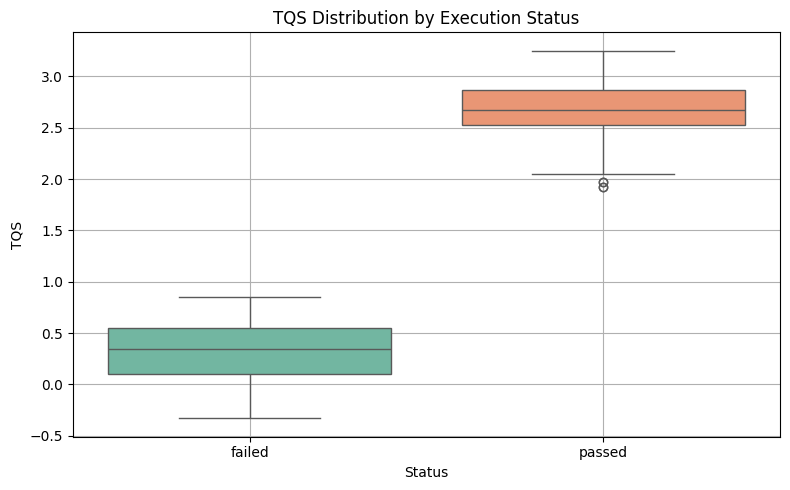

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)


# Carregar o dataset
with open('dataset.json', encoding='utf-8') as f:
    data = json.load(f)

df1 = pd.DataFrame(data)

df = df1[df1['status'] != 'no_code_found']

# Gráfico boxplot do score por status
plt.figure(figsize=(8, 5))
sns.boxplot(x='status', y='score', data=df, palette='Set2')
plt.title('TQS Distribution by Execution Status')
plt.xlabel('Status')
plt.ylabel('TQS')
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Victor.Alves\AppData\Local\Temp\ipykernel_9768\627780442.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='status', y='score', data=df, palette='Set2')


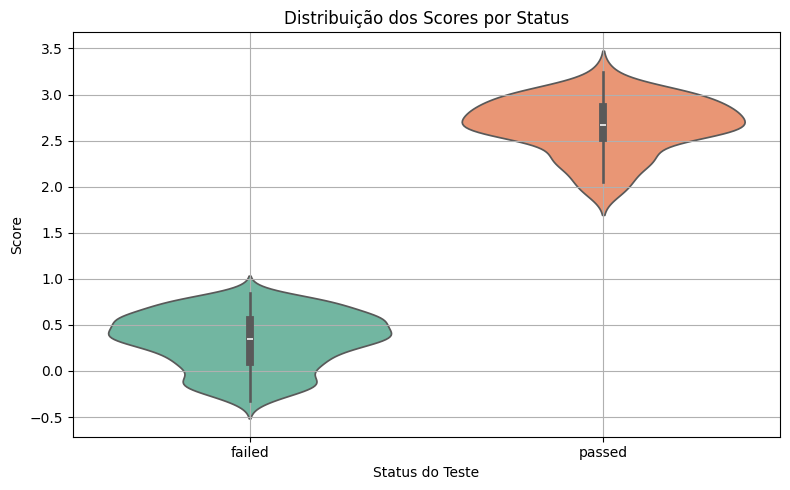

In [13]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='status', y='score', data=df, palette='Set2')
plt.title('Distribuição dos Scores por Status')
plt.xlabel('Status do Teste')
plt.ylabel('Score')
plt.grid(True)
plt.tight_layout()
plt.show()

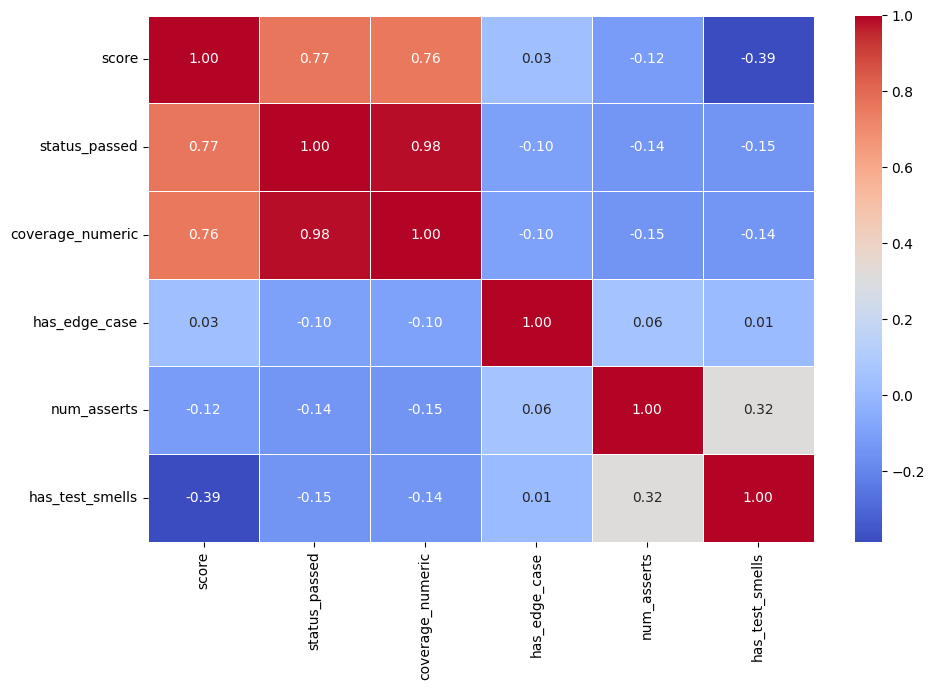

In [6]:


df['coverage_numeric'] = pd.to_numeric(df['coverage'].str.replace('%', ''), errors='coerce')
# Substitui valores ausentes por 0
df['coverage_numeric'] = df['coverage_numeric'].fillna(0)
df['has_test_smells'] = df['test_smells'].apply(lambda x: x != '{}' and pd.notna(x)).astype(int)

# Reconstrói as variáveis numéricas (caso ainda não tenha)
df['has_edge_case'] = df['edge_case_found'].astype(bool).astype(int)
df['num_asserts'] = df['assert_types'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)
df['status_passed'] = df['status'].apply(lambda x: 1 if x == 'passed' else 0)

# Matriz de correlação com valores completos
corr_df = df[['score', 'status_passed', 'coverage_numeric', 'has_edge_case', 'num_asserts','has_test_smells']]
corr_matrix = corr_df.corr(method='spearman')  # ou 'pearson'

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('')
plt.tight_layout()
plt.show()

